# Proyecto de evaluación.
### Andre Julian Gutierrez Alcazar



| Métrica | Qué es | Lado |
|---|---|---|
| `dc_current` | corriente que entra de los paneles | Entrada (DC) |
| `dc_voltage` | voltaje que entra de los paneles | Entrada (DC) |
| `ac_current` | corriente que sale hacia la red | Salida (AC) |
| `ac_voltage` | voltaje que sale hacia la red | Salida (AC) |
| `ac_power` | **potencia** entregada (energía útil generada) | Salida (AC) |

`ac_power` es la métrica estrella: es cuánta energía útil produjo el inversor.
Por eso **de noche vale `0.0`** (sin sol no se genera; no es un dato faltante).

### El problema que queremos resolver ( eso creo yo vea)
Una planta solar es una inversión de millones. Al operador le importan 3 cosas:
- **¿Está fallando algún inversor?** 
- **¿Cómo se comporta la planta en distintos días?** 
- **¿Cuánta energía producirá?** 

> **Pregunta central:** con 6 años de mediciones de 24 inversores, ¿podemos
> **detectar fallas**, **entender patrones de operación** y **predecir la
> producción** de una planta solar?



In [68]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from statsmodels.tsa.seasonal import seasonal_decompose

In [30]:
path = os.getcwd()
print(path)
os.path.exists("data/2107_electrical_data.csv") 

c:\Users\Andre\Documentos\9noCuatri\Mineria_de_datos\corte2eva


True

## Paso 1: unvistzo al dataset

un vistaso rapido!

In [10]:
muestra = pd.read_csv("data/2107_electrical_data.csv", parse_dates=["measured_on"])

print("Filas x columnas (muestra):", muestra.shape)
muestra.head()

Filas x columnas (muestra): (632952, 120)


,measured_on,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
0,2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-11-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-11-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017-11-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017-11-01 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# dtypes: qué tipo de dato interpaeta pandas en cada columna
muestra.dtypes.value_counts()

float64           119
datetime64[us]      1
Name: count, dtype: int64

In [12]:
nulos = muestra.isna().sum()
nulos[nulos > 0].sort_values(ascending=False)

inv_05_ac_current_inv_149601    1728
inv_05_ac_voltage_inv_149602    1728
inv_04_ac_voltage_inv_149597    1728
inv_04_ac_current_inv_149596    1728
inv_05_dc_current_inv_149599    1728
                                ... 
inv_02_dc_voltage_inv_149585     366
inv_02_dc_current_inv_149584     366
inv_01_ac_power_inv_149583       366
inv_01_dc_voltage_inv_149580     366
inv_01_dc_current_inv_149579     366
Length: 114, dtype: int64

In [14]:
# firltrare por hora de mediodia para ver mejor los datos
muestra[muestra["measured_on"].dt.hour == 12]

,measured_on,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
144,2017-11-01 12:00:00,34.296,672.155,26.346,289.784,22.657,34.915,670.401,26.358,290.056,...,41.583,670.084,31.500,290.857,27.258,41.456,674.560,31.610,290.367,27.396
145,2017-11-01 12:05:00,34.648,671.203,26.587,288.876,22.789,35.144,670.802,26.616,289.058,...,42.096,669.533,31.952,290.470,27.606,41.715,673.808,32.106,290.069,27.746
146,2017-11-01 12:10:00,34.531,669.716,26.650,289.616,22.845,35.064,668.731,26.629,289.499,...,41.773,666.811,31.801,290.522,27.485,41.845,671.236,31.945,289.719,27.640
147,2017-11-01 12:15:00,34.913,664.489,26.528,289.706,22.830,35.445,663.604,26.507,289.694,...,41.876,662.418,31.766,290.896,27.484,42.262,667.162,31.973,290.379,27.693
148,2017-11-01 12:20:00,34.501,664.489,26.498,290.328,22.839,35.268,666.644,26.282,290.224,...,42.050,659.413,31.769,290.909,27.498,42.624,663.688,31.910,290.780,27.662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632815,2023-11-07 12:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
632816,2023-11-07 12:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
632817,2023-11-07 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
632818,2023-11-07 12:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# dos coistas:
# inv_05 no debería tener columna dc_voltage
# hay una columna con nombre inconsistente (ac_power_iinv_... en vez de ac_power_inv_...)
cols_inv05 = [c for c in muestra.columns if c.startswith("inv_05_")]
cols_raros = [c for c in muestra.columns if "iinv" in c]

print("Columnas de inv_05:", cols_inv05)
print("Columnas con iinv:", cols_raros)

Columnas de inv_05: ['inv_05_dc_current_inv_149599', 'inv_05_ac_current_inv_149601', 'inv_05_ac_voltage_inv_149602', 'inv_05_ac_power_inv_149603']
Columnas con iinv: ['inv_15_ac_power_iinv_149653']


In [ ]:
# periodo
print("Desde:", muestra["measured_on"].min())
print("Hasta:", muestra["measured_on"].max())
print("Total filas:", len(muestra))

total_celdas = muestra.shape[0] * (muestra.shape[1] - 1) 
total_nulos = muestra.drop(columns="measured_on").isna().sum().sum()
print(f"% nulos global: {100 * total_nulos / total_celdas:.3f}%")

Desde: 2017-11-01 00:00:00
Hasta: 2023-11-07 23:55:00
Total filas: 632952
% nulos global: 0.243%


## Paso 2: Inicio del EDA 

**EDA = Exploratory Data Analysis** (Análisis Exploratorio de Datos): conocer
el dataset a fondo antes de modelar.

Cargamos el dataset de forma **canónica**: convertimos `measured_on` a
`datetime` y lo ponemos como **índice**

Con esto respondemos:
- ¿Cuántos registros y columnas hay?
- ¿Qué tipos de datos hay?
- ¿Qué significan las columnas?
- ¿Hay duplicados? ¿Cuál es el rango de fechas?
- ¿Cuál es la calidad (nulos)?

In [ ]:
#ultimas 
df = pd.read_csv(
    "data/2107_electrical_data.csv",
    parse_dates=["measured_on"],
    index_col="measured_on",
)

print("Registros (filas):", df.shape[0])
print("Columnas de medición:", df.shape[1])
print("Tipo del índice:", df.index.dtype)

df.tail()

Registros (filas): 632952
Columnas de medición: 119
Tipo del índice: datetime64[us]


,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,inv_02_ac_power_inv_149588,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
measured_on,,,,,,,,,,,,,,,,,,,,,
2023-11-07 23:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-07 23:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-07 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-07 23:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-07 23:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#medio 

medio = len(df) // 2
df.iloc[medio : medio + 5, :6]  

,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584
measured_on,,,,,,
2020-11-04 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0
2020-11-04 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0
2020-11-04 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0
2020-11-04 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0
2020-11-04 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# medio
import re

filas = []
for c in df.columns:
    m = re.match(r"^(inv_\d{2})_(.+)_i?inv_\d+$", c) 
    if m:
        filas.append({"inversor": m.group(1), "metrica": m.group(2)})

cols_info = pd.DataFrame(filas)
print("Inversores distintos:", cols_info["inversor"].nunique())
print("\nMétricas y cuántos inversores reportan cada una:")
print(cols_info["metrica"].value_counts())

Inversores distintos: 24

Métricas y cuántos inversores reportan cada una:
metrica
dc_current    24
ac_current    24
ac_voltage    24
ac_power      24
dc_voltage    23
Name: count, dtype: int64


In [ ]:
# mapa inversor por metrica:  1 = ese inversor reporta eso 
# para ver de un vistazo quién NO tiene alguna metic rapido
mapa = pd.crosstab(cols_info["inversor"], cols_info["metrica"])
mapa

metrica,ac_current,ac_power,ac_voltage,dc_current,dc_voltage
inversor,,,,,
inv_01,1,1,1,1,1
inv_02,1,1,1,1,1
inv_03,1,1,1,1,1
inv_04,1,1,1,1,1
inv_05,1,1,1,1,0
inv_06,1,1,1,1,1
inv_07,1,1,1,1,1
inv_08,1,1,1,1,1
inv_09,1,1,1,1,1


In [26]:
# duplicados
print("Timestamps repetidos (índice):", df.index.duplicated().sum())
print("Filas completamente idénticas:", df.duplicated().sum())

print("\nDesde:", df.index.min())
print("Hasta:", df.index.max())
print("¿Índice ordenado?:", df.index.is_monotonic_increasing)

Timestamps repetidos (índice): 0
Filas completamente idénticas: 305213

Desde: 2017-11-01 00:00:00
Hasta: 2023-11-07 23:55:00
¿Índice ordenado?: True


### Más preguntas de exploración

Ya sabemos la forma y el significado. Ahora preguntamos por el **contenido**:
- ¿Qué rangos (mín, máx, promedio) tienen las mediciones? ¿Hay valores imposibles?
- ¿El muestreo cada 5 minutos es regular, o faltan momentos en el tiempo?

In [ ]:
# mas data
cols_inv01 = [c for c in df.columns if c.startswith("inv_01_")]
df[cols_inv01].describe()

,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583
count,632586.000000,632586.000000,632586.000000,632586.000000,632586.000000
mean,9.856498,319.205209,7.454513,136.362110,6.363338
std,15.343311,337.317409,11.367359,143.161743,9.933949
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.029000,675.261000,12.696000,286.213000,10.763000
max,52.348000,909.840000,36.363000,310.677000,30.096000


In [ ]:
# los 5 minutos son contantes?
esperados = pd.date_range(start=df.index.min(), end=df.index.max(), freq="5min")

print("Registros reales:   ", len(df))
print("Registros esperados:", len(esperados))
print("Timestamps faltantes:", len(esperados) - len(df))

Registros reales:    632952
Registros esperados: 633024
Timestamps faltantes: 72


## Paso 3: Calidad de datos (diagnóstico)

encontar lo malo

- hay valores imposibles?
- donde nde están los faltantes: dispersos o al final? 


In [ ]:
# valores imposibles?????
negativos = (df < 0).sum()
print("Total de valores negativos en todo el dataset:", int(negativos.sum()))
print("Columnas con al menos un negativo:", int((negativos > 0).sum()))

Total de valores negativos en todo el dataset: 0
Columnas con al menos un negativo: 0


In [ ]:
filas_vacias = df[df.isna().all(axis=1)]
print("Filas 100% vacías:", len(filas_vacias))
if len(filas_vacias):
    print("Van desde:", filas_vacias.index.min())
    print("Hasta:   ", filas_vacias.index.max())

Filas 100% vacías: 0


## Paso 4: EDA visual básico — distribuciones y atípicos

donde se concentran los valores? hay puntos atipicos? 

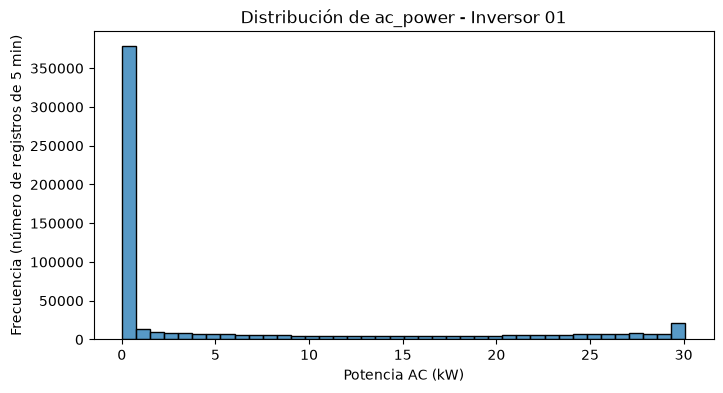

In [35]:
plt.figure(figsize=(8, 4))
sns.histplot(df["inv_01_ac_power_inv_149583"].dropna(), bins=40)
plt.title("Distribución de ac_power - Inversor 01")
plt.xlabel("Potencia AC (kW)")
plt.ylabel("Frecuencia (número de registros de 5 min)")
plt.show()

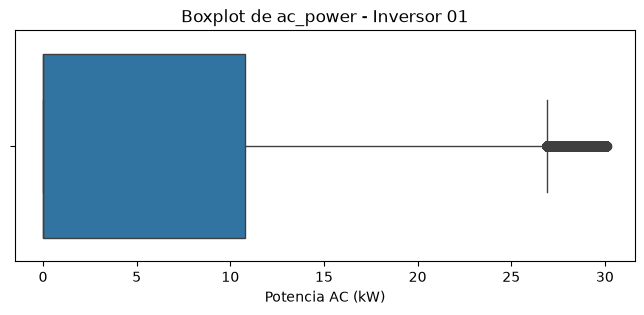

In [36]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["inv_01_ac_power_inv_149583"].dropna())
plt.title("Boxplot de ac_power - Inversor 01")
plt.xlabel("Potencia AC (kW)")
plt.show()


In [37]:
col = df["inv_01_ac_power_inv_149583"].dropna()
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

atipicos = col[(col < limite_inferior) | (col > limite_superior)]
print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"Límites IQR: [{limite_inferior:.2f}, {limite_superior:.2f}]")
print(f"Puntos fuera del rango IQR: {len(atipicos)} de {len(col)} ({100*len(atipicos)/len(col):.2f}%)")


Q1=0.00, Q3=10.76, IQR=10.76
Límites IQR: [-16.14, 26.91]
Puntos fuera del rango IQR: 47075 de 632586 (7.44%)


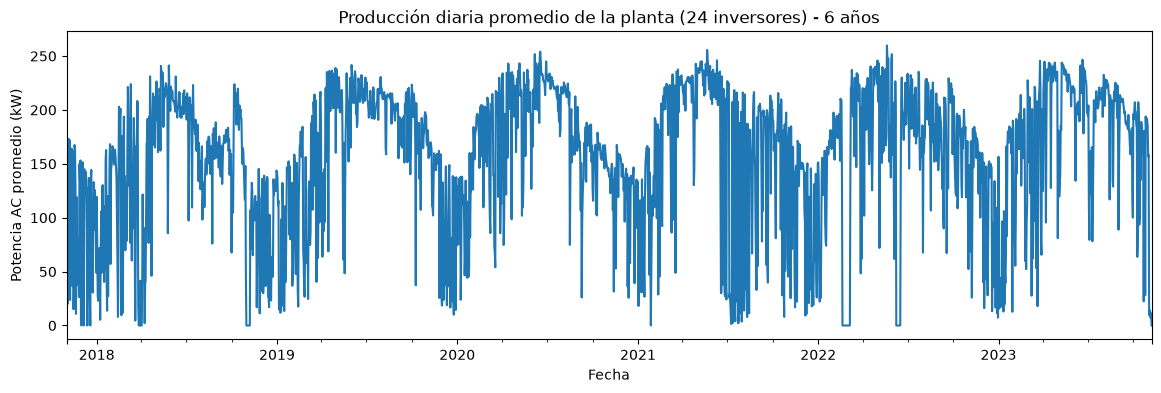

In [ ]:
cols_ac_power = [c for c in df.columns if "ac_power" in c]
potencia_planta = df[cols_ac_power].sum(axis=1)

potencia_diaria = potencia_planta.resample("D").mean()

plt.figure(figsize=(14, 4))
potencia_diaria.plot()
plt.title("Producción diaria promedio de la planta (24 inversores) - 6 años")
plt.xlabel("Fecha")
plt.ylabel("Potencia AC promedio (kW)")
plt.show()


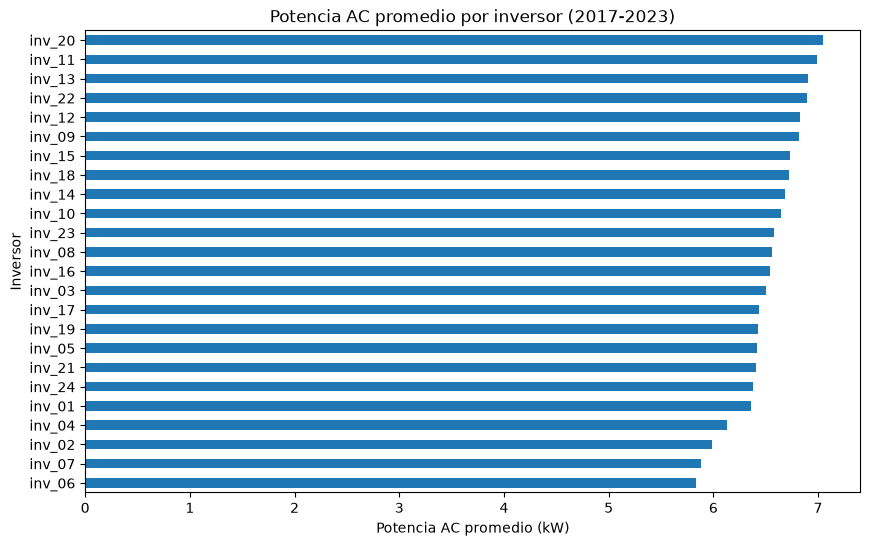

In [ ]:
# potencia AC promedio de cada inversor
medias = df[cols_ac_power].mean()
medias.index = [re.match(r"(inv_\d{2})", c).group(1) for c in medias.index]
medias = medias.sort_values()

plt.figure(figsize=(10, 6))
medias.plot(kind="barh")
plt.title("Potencia AC promedio por inversor (2017-2023)")
plt.xlabel("Potencia AC promedio (kW)")
plt.ylabel("Inversor")
plt.show()


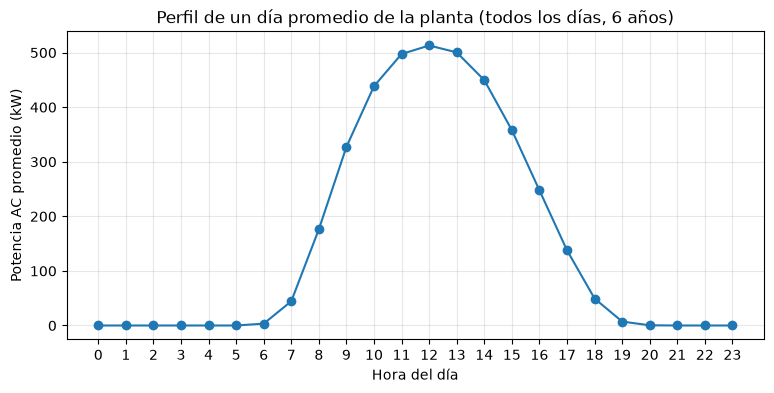

In [81]:
# todos los dias por 6 años jeje
perfil_diario = potencia_planta.groupby(potencia_planta.index.hour).mean()

plt.figure(figsize=(9, 4))
perfil_diario.plot(marker="o")
plt.title("Perfil de un día promedio de la planta (todos los días, 6 años)")
plt.xlabel("Hora del día")
plt.ylabel("Potencia AC promedio (kW)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

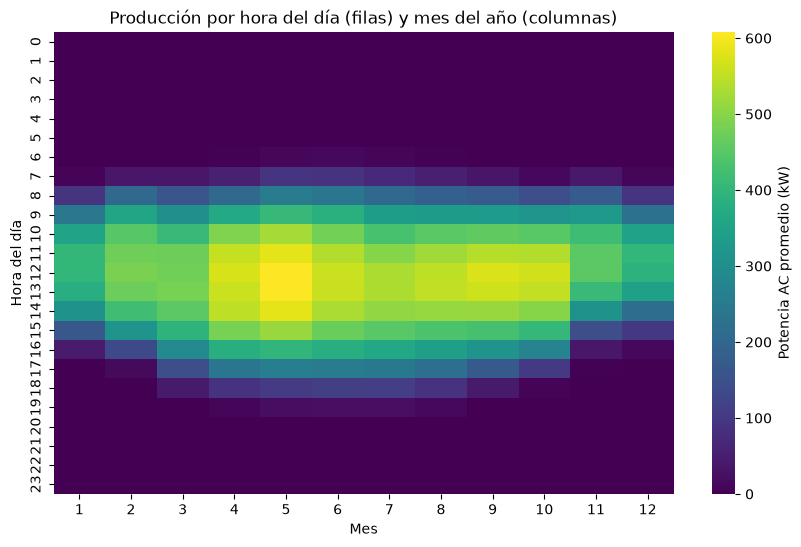

In [ ]:
# Producción promedio por (hora del día, mes del año)
serie = potencia_planta
tabla = serie.groupby([serie.index.hour, serie.index.month]).mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(tabla, cmap="viridis", cbar_kws={"label": "Potencia AC promedio (kW)"})
plt.title("Producción por hora del día (filas) y mes del año (columnas)")
plt.xlabel("Mes")
plt.ylabel("Hora del día")
plt.show()


## Paso 5: Relaciones entre variables (bivariado + correlación)

cómo se **relacionan** entre sí? 

**Correlación**: número entre -1 y 1 que mide si dos variables suben/bajan
juntas.
- Cerca de **+1** → suben juntas
- Cerca de **0** → no hay relación lineal.
- Cerca de **-1** → cuando una sube, la otra baja.

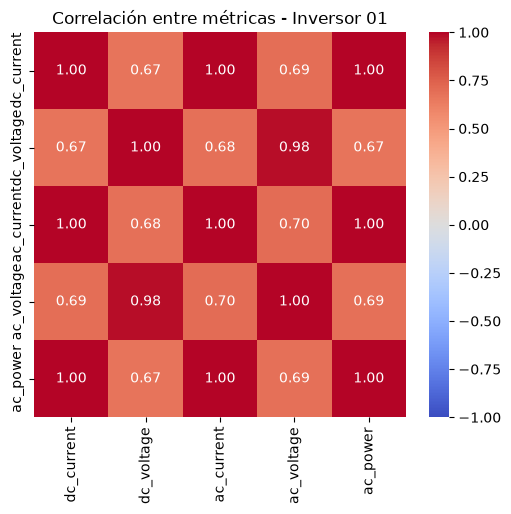

In [ ]:
corr = df[cols_inv01].corr()

etiquetas = [re.search(r"(dc_current|dc_voltage|ac_current|ac_voltage|ac_power)", c).group(1)
             for c in cols_inv01]

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=etiquetas, yticklabels=etiquetas)
plt.title("Correlación entre métricas - Inversor 01")
plt.show()

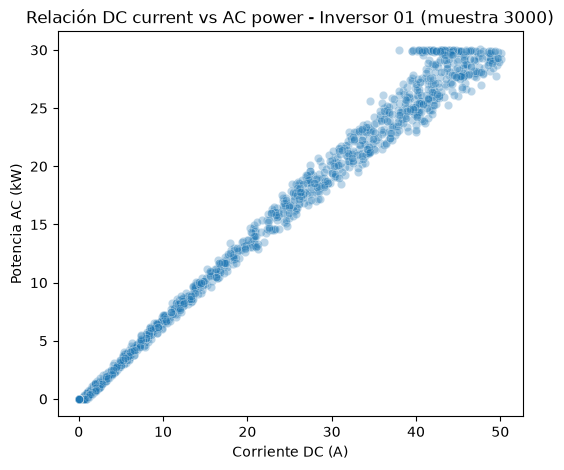

In [ ]:
muestra_scatter = df[cols_inv01].sample(3000, random_state=42)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=muestra_scatter["inv_01_dc_current_inv_149579"],
                y=muestra_scatter["inv_01_ac_power_inv_149583"], alpha=0.3)
plt.title("Relación DC current vs AC power - Inversor 01 (muestra 3000)")
plt.xlabel("Corriente DC (A)")
plt.ylabel("Potencia AC (kW)")
plt.show()

## Comparación de los 24 inversores

¿Alguno produce **sistemáticamente menos**? Ojo con la palabra: no basta el
promedio (un inversor pudo estar apagado 3 meses y aun así tener buen
promedio). "Sistemáticamente" = consistentemente bajo **a lo largo del tiempo**.

Por eso miramos dos cosas:
1. **Barplot** del promedio por inversor + línea de referencia (promedio de la
   flota) → ranking general.
2. **Boxplot** de la producción diaria por inversor → muestra la *consistencia*
   (si un inversor bajo lo es siempre o solo tuvo un mal rato).

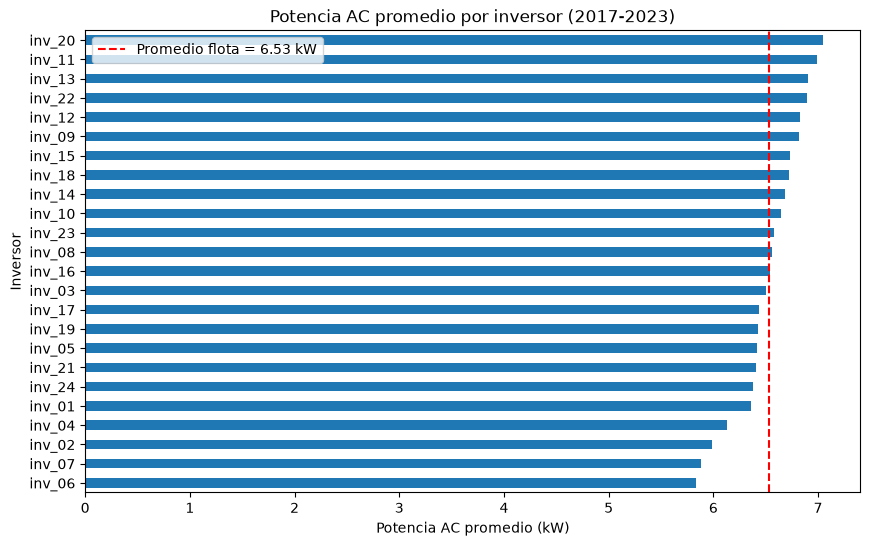

Más bajo:  inv_06 = 5.83 kW
Más alto:  inv_20 = 7.05 kW
Diferencia máx-mín: 20.8% respecto al más bajo


In [ ]:
medias = df[cols_ac_power].mean()
medias.index = [re.match(r"(inv_\d{2})", c).group(1) for c in medias.index]
medias = medias.sort_values()

promedio_flota = medias.mean()

plt.figure(figsize=(10, 6))
medias.plot(kind="barh")
plt.axvline(promedio_flota, color="red", linestyle="--",
            label=f"Promedio flota = {promedio_flota:.2f} kW")
plt.title("Potencia AC promedio por inversor (2017-2023)")
plt.xlabel("Potencia AC promedio (kW)")
plt.ylabel("Inversor")
plt.legend()
plt.show()

# Cuantificamos las diferencias
print(f"Más bajo:  {medias.idxmin()} = {medias.min():.2f} kW")
print(f"Más alto:  {medias.idxmax()} = {medias.max():.2f} kW")
print(f"Diferencia máx-mín: {100*(medias.max()-medias.min())/medias.min():.1f}% respecto al más bajo")

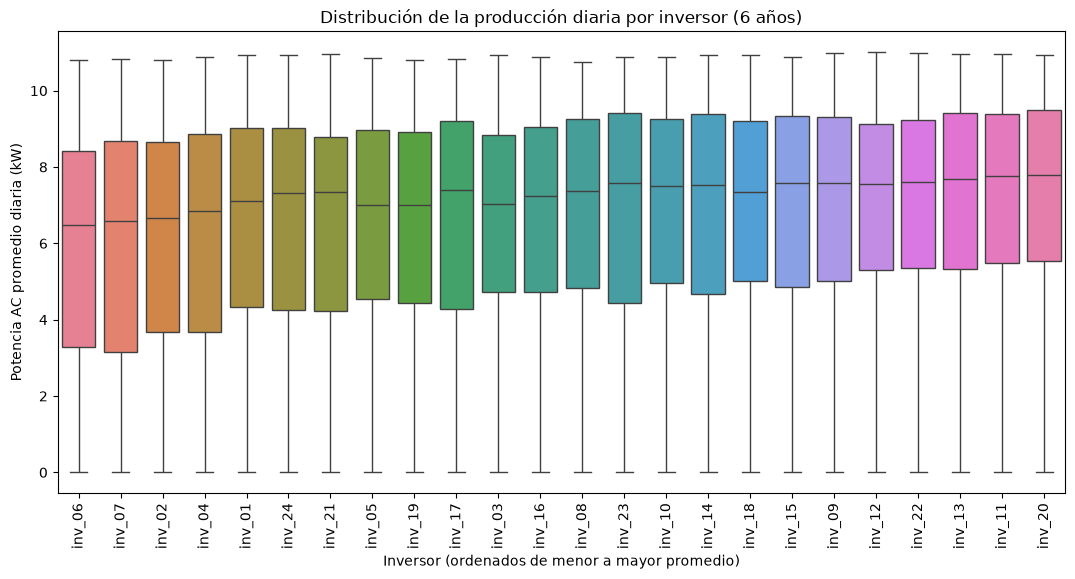

In [45]:
# Boxplot de la producción DIARIA por inversor -> ¿el bajo lo es siempre?
# resample("D").mean() = una fila por día, una columna por inversor.
prod_diaria_inv = df[cols_ac_power].resample("D").mean()
prod_diaria_inv.columns = [re.match(r"(inv_\d{2})", c).group(1) for c in prod_diaria_inv.columns]

# Ordenamos las columnas de menor a mayor producción media (mismo orden que el barplot)
orden = prod_diaria_inv.mean().sort_values().index

plt.figure(figsize=(13, 6))
sns.boxplot(data=prod_diaria_inv[orden])
plt.xticks(rotation=90)
plt.title("Distribución de la producción diaria por inversor (6 años)")
plt.xlabel("Inversor (ordenados de menor a mayor promedio)")
plt.ylabel("Potencia AC promedio diaria (kW)")
plt.show()

# Preguntas del proyecto


| # | Técnica | Pregunta | Objetivo (target) |
|---|---|---|---|
| **S1** | Aprendizaje supervisado (**regresión**) | ¿Podemos predecir la potencia AC de un inversor a partir de sus corrientes y voltajes? | `ac_power` de un inversor |
| **C1** | Aprendizaje no supervisado (**clustering**) | ¿Qué "días típicos" de operación existen (soleado, nublado, con falla)? | Grupos de días según su perfil de 24 h |
| **F1** | Series de tiempo (**forecasting**) | ¿Podemos pronosticar la producción diaria de la planta? | Producción total diaria futura |

**Evidencia del EDA que respalda cada una:**
- **S1** → la correlación entre corriente y `ac_power` es ~1.00 (relación casi perfecta).
- **C1** → los perfiles diarios varían mucho (días soleados vs. nublados en la serie de 6 años).
- **F1** → hay estacionalidad clarísima (6 ciclos anuales) y sin degradación → es predecible.

# Paso 7: Limpieza global de datos

Antes de modelar, arreglamos lo que sirve para las **3 preguntas**:

1. **Renombrar** la columna con typo `inv_15_ac_power_iinv_149653` →
   `inv_15_ac_power_inv_149653` (consistencia de nombres).
2. **Documentar los 72 timestamps faltantes.** Descubrimos que son **6 bloques
   de 12**, todos el segundo domingo de marzo entre las 02:00 y 02:55 AM
   (2018-2023). Es el **cambio de horario de verano (DST)**: a las 2 AM el reloj
   salta a las 3 AM, así que esa hora no existe.

**Decisión:** los dejamos como están **ahora** (caen de madrugada = producción 0,
no afectan a S1 ni C1). Solo reindexaremos la serie **cuando lleguemos a F1**
(forecasting), donde se necesita una rejilla temporal regular.

In [ ]:
# 1) Renombrar la columna con typo (iinv -> inv) para tener nombres consistentes.
df = df.rename(columns={"inv_15_ac_power_iinv_149653": "inv_15_ac_power_inv_149653"})

# Verificamos que ya no queda ninguna columna con 'iinv'
print("Columnas con 'iinv' tras el rename:", [c for c in df.columns if "iinv" in c])
print("¿Existe el nombre corregido?:", "inv_15_ac_power_inv_149653" in df.columns)

In [ ]:
# 2) Análisis de los 72 timestamps faltantes: ¿dispersos o en bloques?
esperados = pd.date_range(start=df.index.min(), end=df.index.max(), freq="5min")
faltantes = esperados.difference(df.index)

# Agrupamos faltantes consecutivos (separados por 5 min) en "bloques"
d = faltantes.to_series().diff()
bloques = (d != pd.Timedelta("5min")).cumsum()

print("Total faltantes:", len(faltantes))
print("Número de bloques continuos:", bloques.nunique())
print("\nInicio -> fin de cada bloque:")
for _, g in faltantes.to_series().groupby(bloques.values):
    print(f"  {g.iloc[0]}  ->  {g.iloc[-1]}   ({len(g)} timestamps)")

# Paso 8: Preparación de datos — S1 (regresión de `ac_power`, inv_01)

Preparamos los datos para la primera pregunta (S1). Objetivo: predecir la
potencia AC del inversor 01 a partir de sus otras métricas.

**Decisiones (con justificación):**
- **Features (X):** `dc_current`, `dc_voltage`, `ac_voltage`. **No** usamos
  `ac_current` aunque correlaciona 1.00 con `ac_power`: es la misma medición de
  salida (sería *data leakage*, casi copiar la respuesta).
- **Target (y):** `ac_power` del inv_01.
- **Partición temporal (no aleatoria):** entrenamos con 2017-2022 y evaluamos
  con 2023. Así imitamos predecir el futuro y evitamos que el modelo "vea"
  datos futuros.

In [46]:
# Armamos features (X) y target (y) del inversor 01, sin ac_current (anti-leakage).
target_col = "inv_01_ac_power_inv_149583"
feature_cols = [
    "inv_01_dc_current_inv_149579",
    "inv_01_dc_voltage_inv_149580",
    "inv_01_ac_voltage_inv_149582",
]

# Solo esas columnas y quitamos filas con NaN (no se entrena con huecos)
datos_s1 = df[feature_cols + [target_col]].dropna()

print("Filas disponibles para S1:", len(datos_s1))
print("Rango de fechas:", datos_s1.index.min(), "->", datos_s1.index.max())

Filas disponibles para S1: 632586
Rango de fechas: 2017-11-01 00:00:00 -> 2023-11-06 17:25:00


In [47]:
# Partición TEMPORAL: train = hasta 2022, test = 2023 en adelante.
corte = "2023-01-01"
train = datos_s1[datos_s1.index < corte]
test = datos_s1[datos_s1.index >= corte]

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print(f"Train (antes de {corte}): {len(train)} filas")
print(f"Test  (desde {corte}):    {len(test)} filas")
print(f"Proporción test: {100*len(test)/len(datos_s1):.1f}%")

Train (antes de 2023-01-01): 543396 filas
Test  (desde 2023-01-01):    89190 filas
Proporción test: 14.1%


# Paso 9: Modelado S1 — Regresión lineal

Entrenamos el modelo más simple (**regresión lineal**) como línea base.
Después lo evaluamos con MAE, RMSE y R² 

In [ ]:
# Entrenamos la regresión lineal (pasado).
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Coeficientes: cuanto pesa cada feature en la predicción
print("Coeficientes (peso de cada variable):")
for f, c in zip(feature_cols, modelo.coef_):
    print(f"  {f}: {c:.4f}")
print("Intercepto:", round(modelo.intercept_, 4))

Coeficientes (peso de cada variable):
  inv_01_dc_current_inv_149579: 0.6496
  inv_01_dc_voltage_inv_149580: 0.0028
  inv_01_ac_voltage_inv_149582: -0.0066
Intercepto: -0.0207


In [49]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f} kW   (error promedio en kW)")
print(f"RMSE: {rmse:.3f} kW   (castiga más los errores grandes)")
print(f"R²:   {r2:.4f}      (0 a 1; qué tanto explica el modelo)")

MAE:  0.466 kW   (error promedio en kW)
RMSE: 0.889 kW   (castiga más los errores grandes)
R²:   0.9929      (0 a 1; qué tanto explica el modelo)


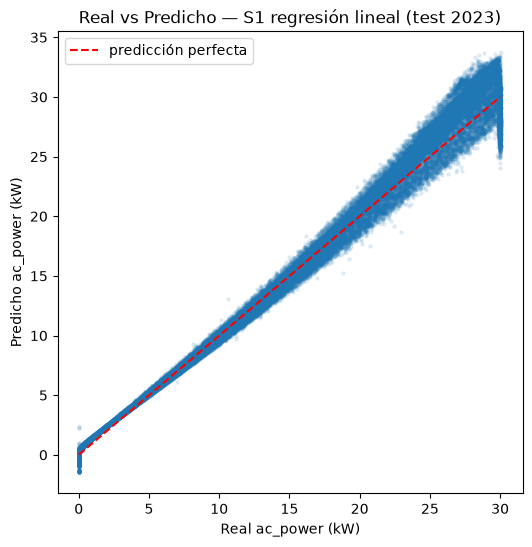

In [50]:
# Vistazo intermedio: real vs predicho. La línea roja = predicción perfecta.
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.1, s=5)
plt.plot([0, 30], [0, 30], "r--", label="predicción perfecta")
plt.xlabel("Real ac_power (kW)")
plt.ylabel("Predicho ac_power (kW)")
plt.title("Real vs Predicho — S1 regresión lineal (test 2023)")
plt.legend()
plt.show()

# Análisis de residuos — ¿cuándo produce menos de lo esperado?

Un **residuo** = valor real − valor predicho.
- Residuo **negativo** → el inversor produjo **MENOS** de lo que el modelo
  esperaba (posible falla, suciedad, sombra).
- Residuo **positivo** → produjo más de lo esperado.

Buscamos **residuos negativos grandes** y en qué **fechas/horas** caen.

el clipping (~30 kW) genera residuos negativos artificiales
en la zona de máxima producción (el modelo predice >30 pero el real está en 30).
Eso NO es falla; hay que separarlo de los déficits reales.

Residuo promedio: -0.193 kW (cerca de 0 = sin sesgo)
Peor déficit (más negativo): -5.08 kW


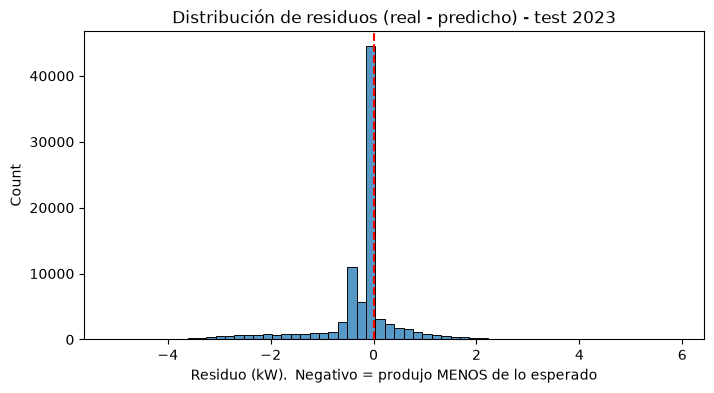

In [51]:
# Residuo = real - predicho. Conserva el índice de fechas del test (2023).
residuos = y_test - y_pred

print(f"Residuo promedio: {residuos.mean():.3f} kW (cerca de 0 = sin sesgo)")
print(f"Peor déficit (más negativo): {residuos.min():.2f} kW")

plt.figure(figsize=(8, 4))
sns.histplot(residuos, bins=60)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribución de residuos (real - predicho) - test 2023")
plt.xlabel("Residuo (kW).  Negativo = produjo MENOS de lo esperado")
plt.show()

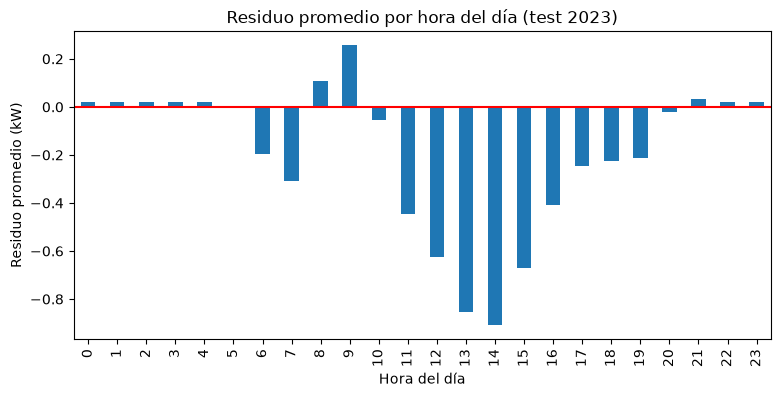

In [ ]:
# a q hora produce menos de lo esperado? Residuo promedio por hora
res_por_hora = residuos.groupby(residuos.index.hour).mean()

plt.figure(figsize=(9, 4))
res_por_hora.plot(kind="bar")
plt.axhline(0, color="red")
plt.title("Residuo promedio por hora del día (test 2023)")
plt.xlabel("Hora del día")
plt.ylabel("Residuo promedio (kW)")
plt.show()

In [ ]:
# q das produjo menos de lo esperado? Días con residuo promedio más negativo
res_por_dia = residuos.resample("D").mean().sort_values()

print("Top 10 días donde el inv_01 produjo MENOS de lo esperado (déficit):")
print(res_por_dia.head(10).round(2))

Top 10 días donde el inv_01 produjo MENOS de lo esperado (déficit):
measured_on
2023-07-22   -1.09
2023-07-01   -1.04
2023-08-16   -1.02
2023-07-21   -1.02
2023-07-02   -1.02
2023-07-15   -0.99
2023-06-30   -0.98
2023-07-20   -0.96
2023-08-15   -0.91
2023-07-14   -0.90
Name: inv_01_ac_power_inv_149583, dtype: float64


# Paso 10: C1 — Clustering de "días típicos"

**Objetivo:** descubrir familias de días de operación (soleado, nublado, posible
falla) agrupando días parecidos, **sin etiquetas** (aprendizaje no supervisado).

**Representación elegida:** cada día = su **perfil horario** (24 columnas =
potencia total promedio por hora). Elegimos esta opción porque captura la
**forma** de la curva, que es lo que distingue un día soleado (campana suave) de
uno nublado (irregular) o con falla (truncada).

Primer paso: construir el dataset "un día por fila".

In [ ]:
# Dataset "un día por fila": filas = días, columnas = 24 horas, valor = potencia
perfil_dia = (
    potencia_planta
    .groupby([potencia_planta.index.date, potencia_planta.index.hour])
    .mean()
    .unstack()  
)

# Quitamos días incompletos 
perfil_dia = perfil_dia.dropna()

print("Forma (días x horas):", perfil_dia.shape)
perfil_dia.head()

Forma (días x horas): (2192, 24)


measured_on,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
2017-11-01,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.856250,100.753583,324.743917,...,542.245500,432.096417,245.363083,47.522250,0.122167,0.0,0.0,0.0,0.0,0.0
2017-11-02,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.281917,13.603667,77.179167,...,219.848250,235.640750,134.407000,18.708667,0.000000,0.0,0.0,0.0,0.0,0.0
2017-11-03,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,10.159083,81.079750,...,82.716833,23.655583,17.605417,3.358500,0.000000,0.0,0.0,0.0,0.0,0.0
2017-11-04,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,5.096500,42.550833,...,490.039833,485.957000,262.817500,51.051667,0.089250,0.0,0.0,0.0,0.0,0.0
2017-11-05,0.0,0.0,0.0,0.0,0.0,0.0,1.268417,95.612250,344.684917,509.134833,...,492.228750,193.865500,52.276083,0.011917,0.000000,0.0,0.0,0.0,0.0,0.0


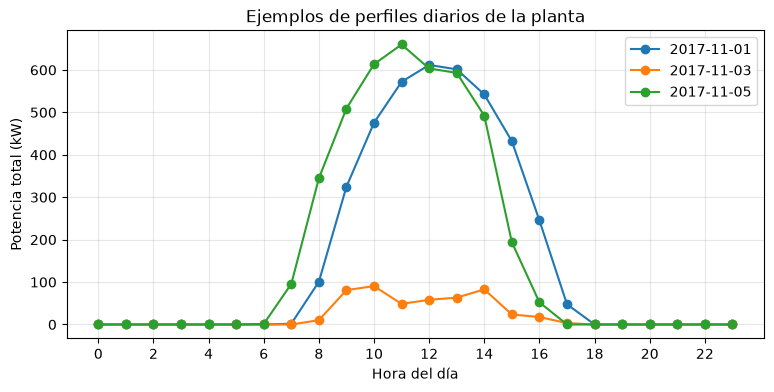

In [55]:
# Vistazo intermedio: 3 perfiles de día para ver que las formas varían.
plt.figure(figsize=(9, 4))
for i in [0, 2, 4]:  # filas 0,2,4 = 2017-11-01, 11-03, 11-05
    plt.plot(range(24), perfil_dia.iloc[i], marker="o", label=str(perfil_dia.index[i]))
plt.title("Ejemplos de perfiles diarios de la planta")
plt.xlabel("Hora del día")
plt.ylabel("Potencia total (kW)")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [56]:
# Escalado: cada hora con media 0 y desviación 1 (K-Means usa distancias).
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(perfil_dia)
print("Forma escalada:", X_scaled.shape)

Forma escalada: (2192, 24)


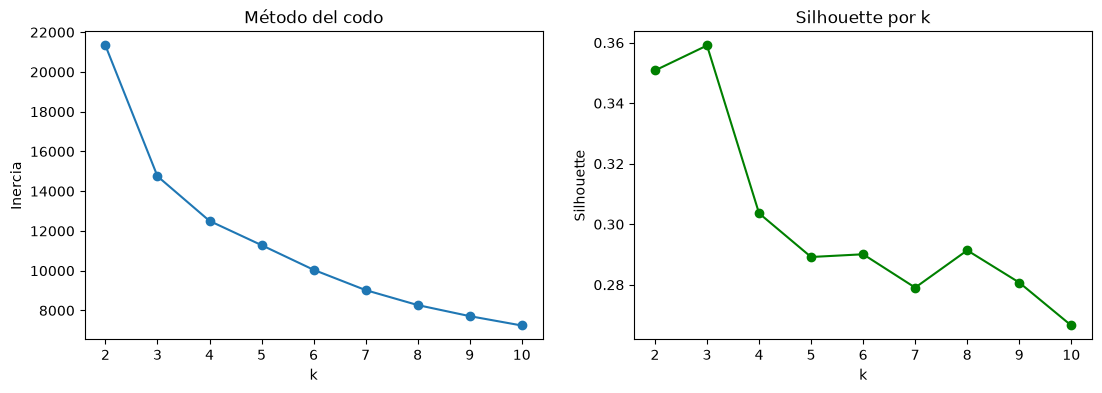

In [57]:
# Elegir k: método del codo (inercia) y silhouette, para k de 2 a 10.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inercias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(list(ks), inercias, marker="o")
ax1.set_title("Método del codo"); ax1.set_xlabel("k"); ax1.set_ylabel("Inercia")
ax2.plot(list(ks), silhouettes, marker="o", color="green")
ax2.set_title("Silhouette por k"); ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette")
plt.show()

### Elección: k = 3

El **codo** se dobla en k=3 y la **silhouette** tiene su pico en k=3 (0.359).
Ambos criterios coinciden → entrenamos K-Means con **k=3** y perfilamos cada
grupo (su curva promedio, cuántos días tiene y ejemplos de fechas).

In [ ]:
# Entrenamos con k=3 y asignamos el cluster a cada día.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

perfil_cl = perfil_dia.copy()
perfil_cl["cluster"] = clusters

print("Días por cluster:")
print(perfil_cl["cluster"].value_counts().sort_index())

Días por cluster:
cluster
0     703
1    1024
2     465
Name: count, dtype: int64


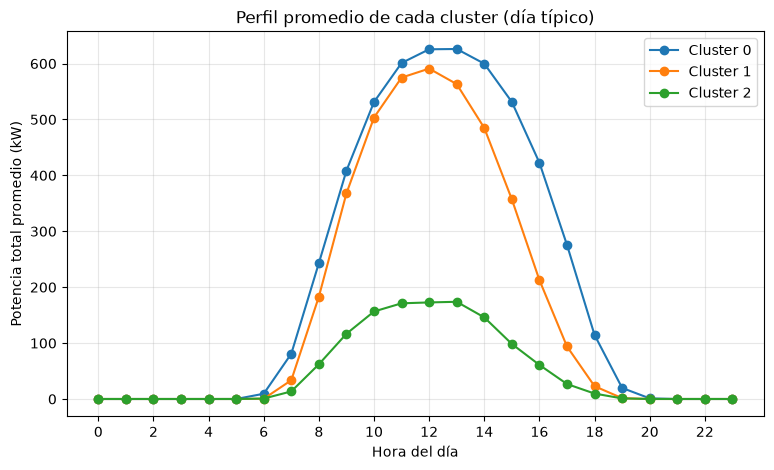

In [59]:
# Perfil promedio de cada cluster (su "día típico") en la escala original.
centroides = perfil_cl.groupby("cluster").mean()

plt.figure(figsize=(9, 5))
for cl in centroides.index:
    plt.plot(range(24), centroides.loc[cl], marker="o", label=f"Cluster {cl}")
plt.title("Perfil promedio de cada cluster (día típico)")
plt.xlabel("Hora del día")
plt.ylabel("Potencia total promedio (kW)")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [60]:
# Energía total media por cluster (suma de las 24 horas) + ejemplos de fechas.
energia_media = centroides.sum(axis=1).round(0)
print("Energía diaria promedio por cluster (suma de horas):")
print(energia_media, "\n")

for cl in sorted(perfil_cl["cluster"].unique()):
    fechas = list(perfil_cl[perfil_cl["cluster"] == cl].index[:5])
    print(f"Cluster {cl}: ejemplos de fechas -> {fechas}")

Energía diaria promedio por cluster (suma de horas):
cluster
0    5091.0
1    3991.0
2    1210.0
dtype: float64 

Cluster 0: ejemplos de fechas -> [datetime.date(2018, 4, 19), datetime.date(2018, 4, 23), datetime.date(2018, 4, 24), datetime.date(2018, 4, 25), datetime.date(2018, 4, 26)]
Cluster 1: ejemplos de fechas -> [datetime.date(2017, 11, 1), datetime.date(2017, 11, 5), datetime.date(2017, 11, 6), datetime.date(2017, 11, 7), datetime.date(2017, 11, 9)]
Cluster 2: ejemplos de fechas -> [datetime.date(2017, 11, 2), datetime.date(2017, 11, 3), datetime.date(2017, 11, 4), datetime.date(2017, 11, 8), datetime.date(2017, 11, 12)]


In [ ]:
nombres_cluster = {
    0: "Alta produccion (soleado, dias largos)",
    1: "Produccion media (el mas comun)",
    2: "Baja produccion (nublado)",
}
perfil_cl["tipo_dia"] = perfil_cl["cluster"].map(nombres_cluster)

print(perfil_cl["tipo_dia"].value_counts())

tipo_dia
Produccion media (el mas comun)           1024
Alta produccion (soleado, dias largos)     703
Baja produccion (nublado)                  465
Name: count, dtype: int64


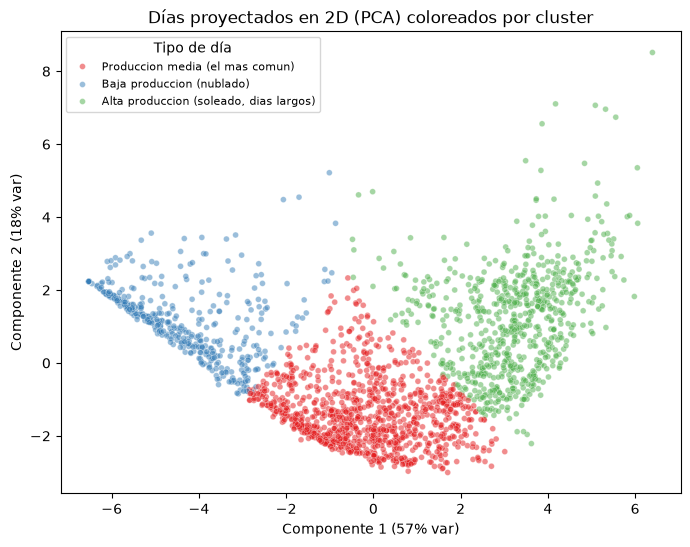

In [63]:


pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1],
                hue=perfil_cl["tipo_dia"].values, palette="Set1", alpha=0.5, s=18)
plt.title("Días proyectados en 2D (PCA) coloreados por cluster")
plt.xlabel(f"Componente 1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)")
plt.ylabel(f"Componente 2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)")
plt.legend(title="Tipo de día", fontsize=8)
plt.show()


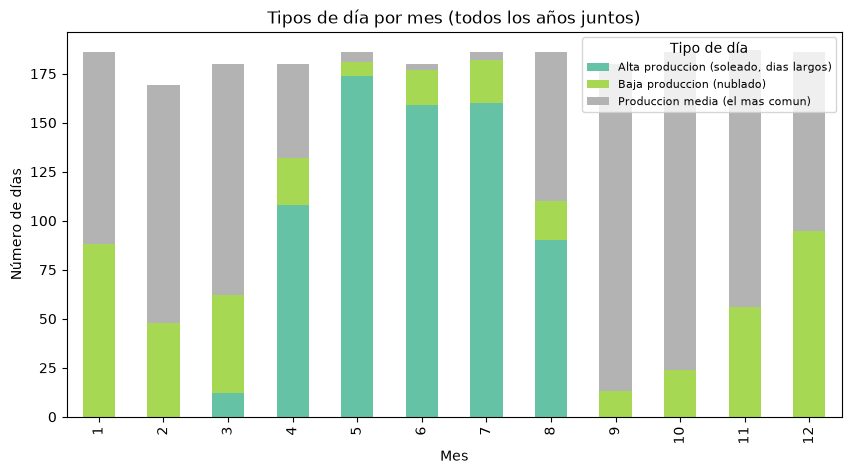

In [64]:
meses = pd.Series([d.month for d in perfil_cl.index], index=perfil_cl.index)
tabla_mes = pd.crosstab(meses, perfil_cl["tipo_dia"])

tabla_mes.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Set2")
plt.title("Tipos de día por mes (todos los años juntos)")
plt.xlabel("Mes")
plt.ylabel("Número de días")
plt.legend(title="Tipo de día", fontsize=8)
plt.show()


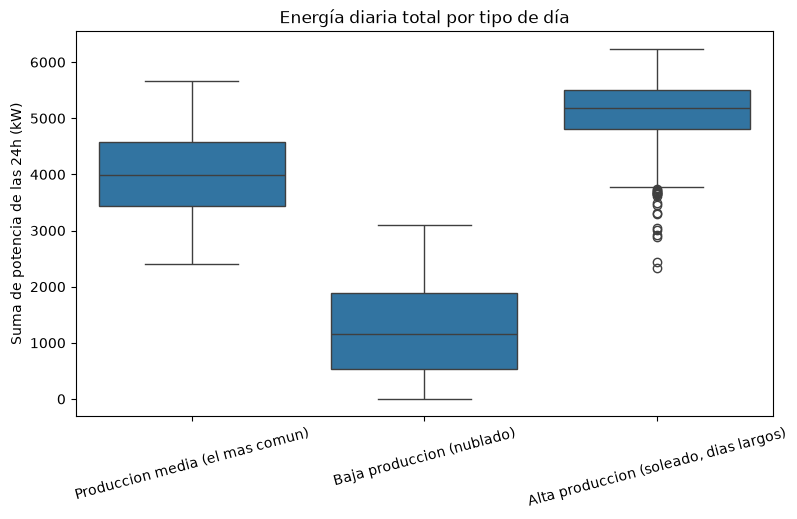

In [65]:
energia_dia = perfil_dia.sum(axis=1)
plot_df = pd.DataFrame({
    "energia_diaria": energia_dia.values,
    "tipo_dia": perfil_cl["tipo_dia"].values,
})

plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x="tipo_dia", y="energia_diaria")
plt.title("Energía diaria total por tipo de día")
plt.xlabel("")
plt.ylabel("Suma de potencia de las 24h (kW)")
plt.xticks(rotation=15)
plt.show()

# Paso 12: F1 — Forecasting de la producción diaria

**Objetivo:** pronosticar la producción diaria de la planta a futuro.

En una **serie de tiempo** el orden cronológico es sagrado (no se baraja).
Primero construimos la serie diaria, la descomponemos en sus partes y luego
entrenamos un modelo, evaluando siempre con partición temporal (pasado → futuro).


### Serie diaria (frecuencia regular)

Agregamos la potencia total de la planta por día (`resample("D").mean()`) y
aseguramos un día por fila con `asfreq("D")`. Los 72 timestamps faltantes del
cambio de horario no afectan aquí porque agregamos por día.


In [66]:
serie_diaria = potencia_planta.resample("D").mean().asfreq("D")
print("Días en la serie:", len(serie_diaria))
print("¿Huecos (NaN)?:", int(serie_diaria.isna().sum()))
serie_diaria.head()


Días en la serie: 2198
¿Huecos (NaN)?: 0


measured_on
2017-11-01    164.819642
2017-11-02     86.450115
2017-11-03     19.965312
2017-11-04    117.459635
2017-11-05    173.303413
Freq: D, dtype: float64

### Descomposición: tendencia + estacionalidad + residuo

`seasonal_decompose` separa la serie en 3 partes (`period=365` = ciclo anual):
- **Tendencia:** dirección de largo plazo (¿degradación con los años?).
- **Estacional:** la onda que se repite cada año (verano alto, invierno bajo).
- **Residuo:** lo que queda; debe verse como ruido sin patrón.


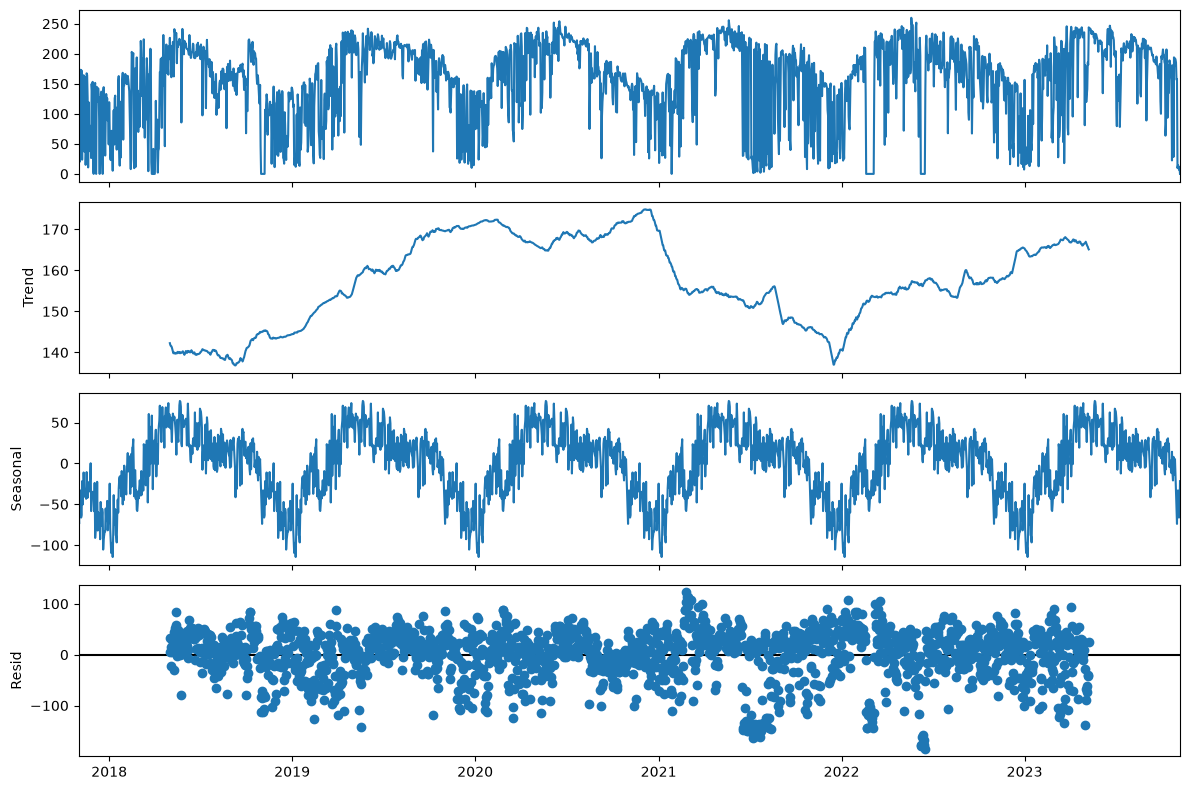

In [ ]:
desc = seasonal_decompose(serie_diaria.ffill(), model="additive", period=365)
fig = desc.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


### Producción diaria por mes

Boxplot de la producción diaria agrupada por mes: muestra la estacionalidad de
forma distribucional (cajas altas en verano, bajas en invierno).


C:\Users\Andre\AppData\Local\Temp\ipykernel_3024\2184505873.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x="mes", y="prod", palette="viridis")


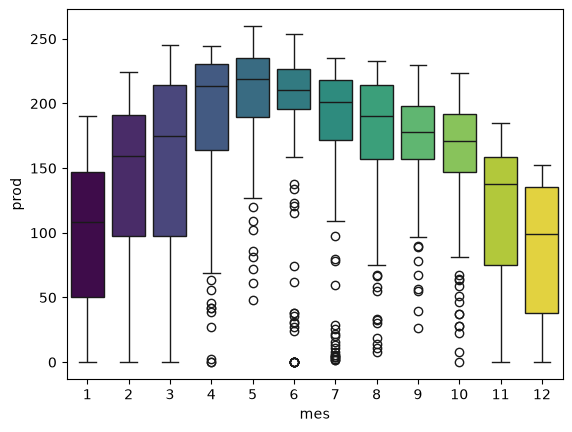

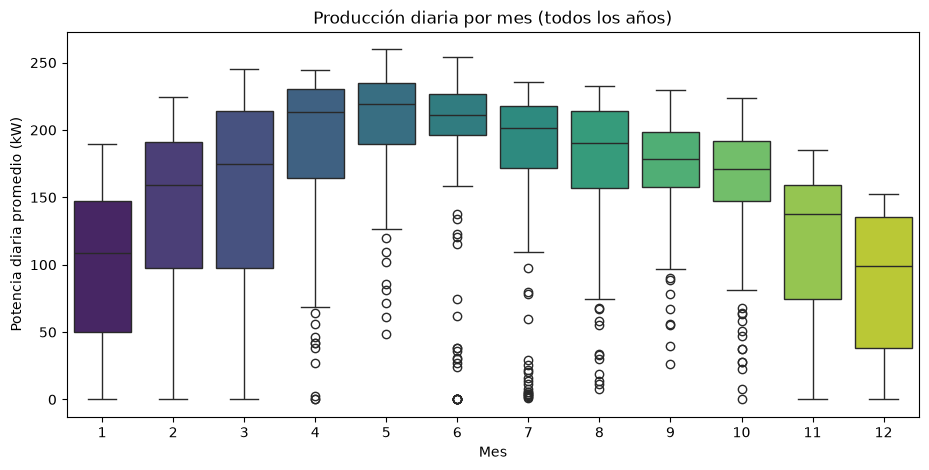

In [73]:
sns.boxplot(data=tmp, x="mes", y="prod", hue="mes", palette="viridis", legend=False)
tmp = serie_diaria.dropna().to_frame("prod")
tmp["mes"] = tmp.index.month



plt.figure(figsize=(11, 5))
sns.boxplot(data=tmp, x="mes", y="prod", palette="viridis")
plt.title("Producción diaria por mes (todos los años)")
plt.xlabel("Mes")
plt.ylabel("Potencia diaria promedio (kW)")

plt.show()


### Partición temporal 

Partimos la serie por fecha (train = pasado, test = 2023). La línea base es un
**naive estacional**: el pronóstico de un día = el valor del mismo día 365 días
antes. Es el mínimo a superar por cualquier modelo.


In [74]:
corte = "2023-01-01"
train = serie_diaria[serie_diaria.index < corte]
test = serie_diaria[serie_diaria.index >= corte]
print(f"Train: {len(train)} días  |  Test: {len(test)} días")


Train: 1887 días  |  Test: 311 días


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

pred_snaive = serie_diaria.shift(365).loc[test.index]

# Alineamos (quitamos posibles NaN)
mask = pred_snaive.notna()
mae_base = mean_absolute_error(test[mask], pred_snaive[mask])
rmse_base = np.sqrt(mean_squared_error(test[mask], pred_snaive[mask]))
print(f"Línea base (naive estacional) -> MAE: {mae_base:.2f} kW | RMSE: {rmse_base:.2f} kW")


Línea base (naive estacional) -> MAE: 58.66 kW | RMSE: 80.01 kW


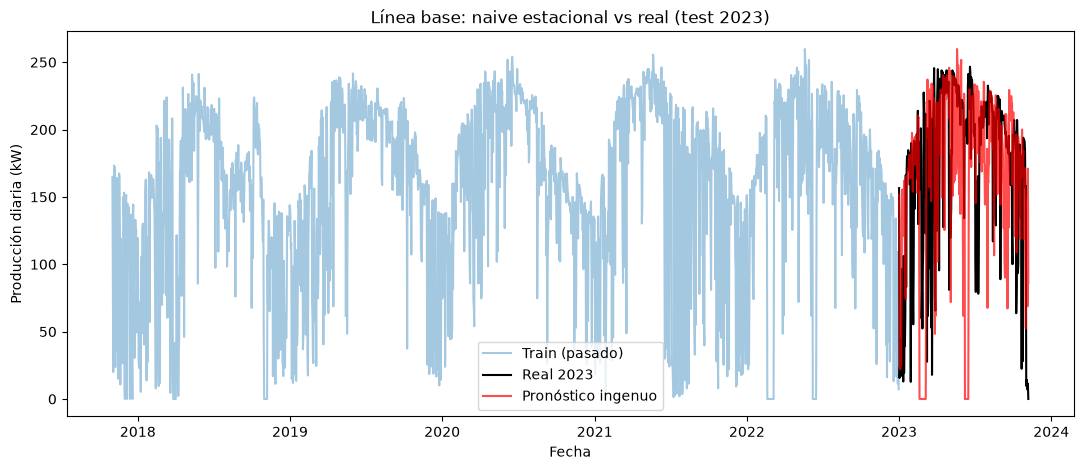

In [76]:
plt.figure(figsize=(13, 5))
plt.plot(train.index, train, label="Train (pasado)", alpha=0.4)
plt.plot(test.index, test, label="Real 2023", color="black", linewidth=1.5)
plt.plot(test.index, pred_snaive, label="Pronóstico ingenuo", color="red", alpha=0.7)
plt.title("Línea base: naive estacional vs real (test 2023)")
plt.xlabel("Fecha")
plt.ylabel("Producción diaria (kW)")
plt.legend()
plt.show()


### Modelos de pronóstico (a superar la línea base de 58.66 kW)

Comparamos dos modelos contra el naive estacional:
- **Climatología:** promedio histórico de cada día del año (reduce ruido).
- **Holt-Winters:** suavizado exponencial con nivel + tendencia + estacionalidad.


In [77]:
# Promedio histórico por día del año, calculado SOLO con el train
train_df = train.to_frame("prod")
train_df["doy"] = train_df.index.dayofyear
clima = train_df.groupby("doy")["prod"].mean()

# Pronóstico: a cada día del test le asignamos el promedio de su día del año
pred_clima = pd.Series(test.index.dayofyear, index=test.index).map(clima)

mae_clima = mean_absolute_error(test, pred_clima)
rmse_clima = np.sqrt(mean_squared_error(test, pred_clima))
print(f"Climatología -> MAE: {mae_clima:.2f} kW | RMSE: {rmse_clima:.2f} kW")


Climatología -> MAE: 45.66 kW | RMSE: 54.85 kW


                    MAE   RMSE
Naive estacional  58.66  80.01
Climatología      45.66  54.85
Holt-Winters      88.85  98.34 



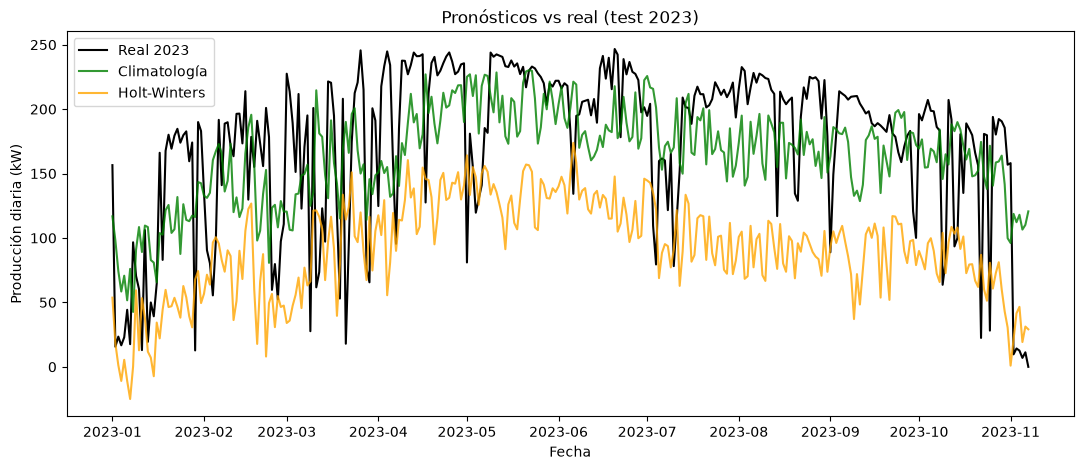

In [80]:
resumen = pd.DataFrame({
    "MAE":  [mae_base, mae_clima, mae_hw],
    "RMSE": [rmse_base, rmse_clima, rmse_hw],
}, index=["Naive estacional", "Climatología", "Holt-Winters"]).round(2)
print(resumen, "\n")

plt.figure(figsize=(13, 5))
plt.plot(test.index, test, label="Real 2023", color="black", linewidth=1.5)
plt.plot(test.index, pred_clima, label="Climatología", color="green", alpha=0.8)
plt.plot(test.index, pred_hw, label="Holt-Winters", color="orange", alpha=0.8)
plt.title("Pronósticos vs real (test 2023)")
plt.xlabel("Fecha"); plt.ylabel("Producción diaria (kW)")
plt.legend()
plt.show()
